# Stress 06 — Geography & Hierarchy: Panels, Pooling, and the Regional ROI Trap

**Series:** *Green diagnostics ≠ correct attribution.* Notebooks
[00](stress_00_the_rosy_picture.ipynb)–[05](stress_05_the_gauntlet.ipynb)
stress-tested the model on **national** time series. Real engagements
increasingly arrive as **panels** — KPI by geography, often by geography ×
product — and panels change the stress surface three ways at once:

| | what a panel adds | what can go wrong |
|---|---|---|
| 🧱 **mechanics** | observations are *stacked* `(week, geo[, product])` cells | any transform that treats the obs axis as time silently mixes geographies (**act 0** — a real bug, found and fixed by this notebook's build) |
| 📊 **resolution** | stakeholders read **regional** ROI, not just national | the model's hierarchy gives each geo an *intercept* offset while every response parameter is **global** — per-geo readouts can fail while the national view stays green (**act 3**) |
| 🔬 **identification** | cross-sectional replication: every week observed in every geo | aggregate it away and you pay in interval width and drifting estimates (**act 2**) |

Worlds come from `tests/synth/dgp_geo.py` — balanced panels with the same
estimand discipline as the rest of the series, except the counterfactual
ground truth is recorded **per geography** (and per cell), so the model can be
graded at the level the budget decisions actually happen.

> Fits: numpyro NUTS, 300 draws × 2 chains (the series' fast config). The
> grading helpers verify, in-notebook, that the model's deterministic
> contribution draws and its counterfactual zero-out agree — same estimand,
> same scale, no apples-to-oranges.

In [1]:
import sys, os, pathlib, time, warnings, logging, contextlib
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
for _n in ("pymc", "pymc.sampling", "numpyro", "jax", "arviz", "pytensor"):
    _lg = logging.getLogger(_n); _lg.setLevel(logging.CRITICAL); _lg.propagate = False
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # repo root (run from nbs/)

@contextlib.contextmanager
def quiet():
    "Hide sampler progress bars/chatter; our own prints stay visible."
    with open(os.devnull, "w") as _dn, contextlib.redirect_stdout(_dn), \
            contextlib.redirect_stderr(_dn):
        yield

from tests.synth import dgp_geo

plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.dpi": 110, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
INK, ACCENT, SKY, BERRY, LEAF, AMBER, MUTED = (
    "#2b2118", "#b5651d", "#3b6ea5", "#a63a50", "#3f7d5e", "#d98a2b", "#8a8079")
PAL = {"TV": ACCENT, "Search": SKY, "Social": BERRY, "Display": LEAF}
GPAL = {"North": SKY, "South": AMBER, "East": LEAF, "West": BERRY}
CH = dgp_geo.CHANNELS
print("geo worlds available:", list(dgp_geo.SCENARIOS))

geo worlds available: ['geo_clean', 'geo_heterogeneous', 'geo_product']


## Shared harness

One fit configuration (the series' fast config), one set of graders. Three
helpers matter here beyond the usual:

- **`per_cell_table`** grades each geography/cell against its own recorded
  truth, using the `channel_contributions` posterior (per-draw, per-week, per
  channel, KPI-scaled) — which the harness first *verifies* matches the
  counterfactual zero-out totals, so the per-geo grades use the same estimand
  as the national ones.
- **`style_grade`** renders grade tables with error gradients and
  coverage marks — read the color, not the digits.
- **`true_cell_path`** restates the DGP's per-cell weekly truth so
  contribution bands can be drawn against the path they claim to estimate.

In [2]:
from mmm_framework.config import InferenceMethod, ModelConfig
from mmm_framework.model import BayesianMMM, TrendConfig, TrendType

DRAWS, CHAINS = 300, 2
SUMMARY = {}

def fit_panel(panel, label):
    cfg = ModelConfig(
        inference_method=InferenceMethod.BAYESIAN_NUMPYRO,
        n_draws=DRAWS, n_tune=DRAWS, n_chains=CHAINS,
        use_parametric_adstock=True, optim_seed=0,
    )
    mmm = BayesianMMM(panel, cfg, TrendConfig(type=TrendType.LINEAR))
    t0 = time.perf_counter()
    with quiet():
        res = mmm.fit(random_seed=0)
    print(f"fit '{label}': {time.perf_counter()-t0:.0f}s   "
          f"r-hat max {res.diagnostics['rhat_max']:.3f}   "
          f"divergences {res.diagnostics['divergences']}   "
          f"min bulk ESS {res.diagnostics['ess_bulk_min']:.0f}")
    return mmm, res

def contrib_draws(mmm, res):
    "channel_contributions posterior -> (n_draws, n_obs, n_channels), KPI scale."
    post = res.trace.posterior["channel_contributions"].values
    return post.reshape(-1, post.shape[2], post.shape[3]) * mmm.y_std

def grade_national(sc_truth, mmm, key, label):
    "Counterfactual zero-out totals vs national truth, with 90% HDI coverage."
    with quiet():
        contrib = mmm.compute_counterfactual_contributions(
            compute_uncertainty=True, hdi_prob=0.9, random_seed=0)
    rows = {}
    for c in CH:
        t, e = float(sc_truth[c]), float(contrib.total_contributions[c])
        lo = float(contrib.contribution_hdi_low[c])
        hi = float(contrib.contribution_hdi_high[c])
        rows[c] = dict(true=t, est=e, rel_err=(e - t) / abs(t),
                       covered=lo <= t <= hi, width=(hi - lo) / abs(t))
    df = pd.DataFrame(rows).T
    SUMMARY[key] = dict(label=label, df=df,
                        med_abs_err=float(df.rel_err.abs().median()),
                        coverage=float(df.covered.mean()),
                        total_err=float((df.est.sum() - df.true.sum()) / df.true.sum()))
    s = SUMMARY[key]
    print(f"{label}:  med|err| {s['med_abs_err']:.0%}   coverage {s['coverage']:.0%}   "
          f"total media {s['total_err']:+.0%}")
    return df, contrib

def cell_labels(sc):
    geo = sc.spend.index.get_level_values("Geography")
    if sc.products:
        prod = sc.spend.index.get_level_values("Product")
        return np.array([f"{g}|{p}" for g, p in zip(geo, prod)])
    return np.array(list(geo))

def per_cell_table(sc, mmm, res, contrib=None):
    "Grade every cell x channel against the recorded per-cell truth."
    draws = contrib_draws(mmm, res)
    if contrib is not None:
        # Estimand identity: deterministic totals == counterfactual totals.
        det = draws.mean(axis=0).sum(axis=0)
        cf = np.array([float(contrib.total_contributions[c]) for c in CH])
        assert np.allclose(det, cf, rtol=0.02), (det, cf)
    labels = cell_labels(sc)
    rows = []
    for cell in sc.cells:
        m = labels == cell
        tot = draws[:, m, :].sum(axis=1)
        for ci, c in enumerate(CH):
            t = float(sc.true_contribution_by_geo.loc[cell, c])
            e = float(tot[:, ci].mean())
            lo, hi = np.percentile(tot[:, ci], [5, 95])
            rows.append(dict(cell=cell, channel=c, true=t, est=e,
                             rel_err=(e - t) / abs(t), covered=lo <= t <= hi))
    return pd.DataFrame(rows)

def style_grade(df):
    "Color-graded national table: error gradient + coverage marks."
    show = df.copy()
    show["covered"] = np.where(show["covered"], "✓ in 90% HDI", "✗ OUTSIDE")
    sty = (show.style
           .format({"true": "{:,.0f}", "est": "{:,.0f}",
                    "rel_err": "{:+.0%}", "width": "{:.2f}"})
           .background_gradient(subset=["rel_err"], cmap="RdBu_r",
                                vmin=-1.0, vmax=1.0)
           .map(lambda v: f"color: {LEAF}; font-weight: 600" if str(v).startswith("✓")
                else f"color: {BERRY}; font-weight: 700", subset=["covered"]))
    return sty

def err_heatmap(ax, piv, title, vmax=1.0):
    "Annotated geo x channel relative-error heatmap."
    im = ax.imshow(piv.values, vmin=-vmax, vmax=vmax, cmap="RdBu_r")
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, fontsize=8)
    ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index, fontsize=8)
    for (i, j), v in np.ndenumerate(piv.values):
        ax.text(j, i, f"{v:+.0%}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.6 * vmax else INK)
    ax.set_title(title, fontsize=10); ax.grid(False)
    return im

def true_cell_path(sc, cell, c):
    "The DGP's true weekly contribution of channel c in one cell (KPI scale)."
    m = cell_labels(sc) == cell
    sp = sc.spend.loc[m, c].to_numpy(float)
    mult = sc.notes.get("effect_multipliers")
    k = 1.0 if mult is None else float(mult[cell.split("|")[0]][c])
    xn = sp / sc.notes["maxes"][c]
    return k * dgp_geo._AMP[c] * dgp_geo._logistic_sat(
        dgp_geo._geom_adstock(xn, dgp_geo._ALPHA[c]), dgp_geo._LAM[c])

---
# Act 0 — The bug the panel surfaced: carryover across the geo boundary

A panel model receives its observations as **one stacked vector** — the MFF
loader orders them period-major: `(week 1, North), (week 1, South), …,
(week 2, North), …`. Adstock is a convolution over *time*. Convolve the
stacked vector directly — which is exactly what the framework did before this
notebook's build — and "lag 1" of every observation is **a different
geography at the same week**. Carryover bleeds sideways: TV aired in the
North adstocks into the South's Tuesday.

Nothing crashes. Sampling converges. The model simply estimates kernels and
contributions for a physically meaningless quantity — the series' definition
of a silent failure, this time *structural* rather than statistical. The fix
(shipped with this work, `transforms/adstock_pt.py::apply_adstock_panel_pt` +
the per-cell legacy path) scatters observations into a `(weeks × cells)`
matrix, convolves along time only, and gathers back.

First, the mechanism in pure NumPy; then the shipped model passes an impulse
isolation test it previously failed.

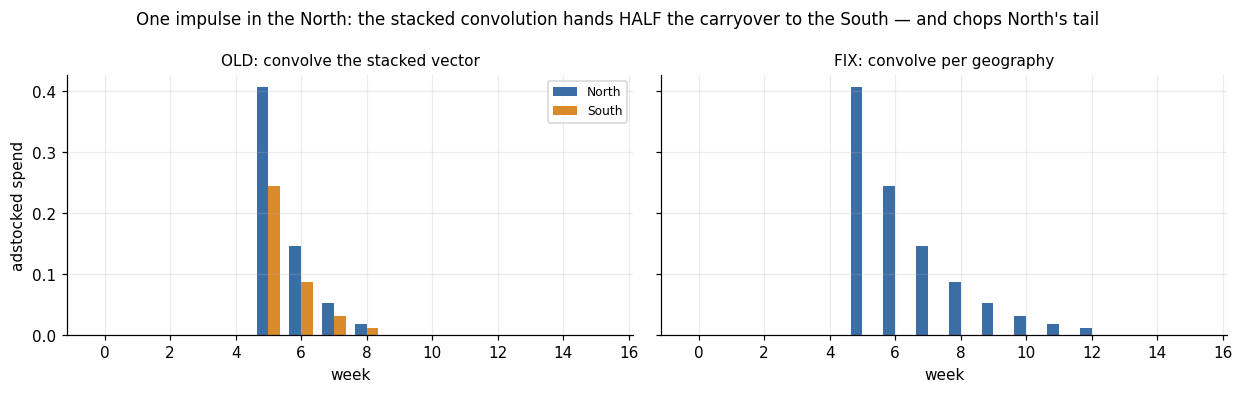

South's share of total adstocked weight — old: 38%, fixed: 0%


In [3]:
# Mechanism: one impulse of spend in North, week 5. Convolve the STACKED
# vector (the old behavior) vs per-cell (the fix).
geos0 = ["North", "South"]
n_wk, l_max = 16, 8
w = 0.6 ** np.arange(l_max); w = w / w.sum()          # geometric kernel
stacked = np.zeros(n_wk * len(geos0))                  # period-major stack
stacked[5 * 2 + 0] = 1.0                               # (week 5, North)

def conv1d(x):
    xp = np.concatenate([np.zeros(l_max - 1), x])
    return np.array([xp[t:t + l_max][::-1] @ w for t in range(len(x))])

old = conv1d(stacked)                                  # the pre-fix arithmetic
new = np.zeros_like(stacked)
for g in range(2):                                     # the per-cell fix
    new[g::2] = conv1d(stacked[g::2])

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6), sharey=True)
for ax, vec, ttl in [(axes[0], old, "OLD: convolve the stacked vector"),
                     (axes[1], new, "FIX: convolve per geography")]:
    ax.bar(np.arange(n_wk) - 0.18, vec[0::2], 0.36, color=GPAL["North"], label="North")
    ax.bar(np.arange(n_wk) + 0.18, vec[1::2], 0.36, color=GPAL["South"], label="South")
    ax.set_title(ttl, fontsize=10); ax.set_xlabel("week")
axes[0].set_ylabel("adstocked spend"); axes[0].legend(fontsize=8)
fig.suptitle("One impulse in the North: the stacked convolution hands HALF the "
             "carryover to the South — and chops North's tail", fontsize=11)
plt.tight_layout(); plt.show()

south_old, south_new = old[1::2].sum(), new[1::2].sum()
print(f"South's share of total adstocked weight — old: "
      f"{south_old / old.sum():.0%}, fixed: {south_new / new.sum():.0%}")
assert south_old > 0.3 * old.sum()      # the old arithmetic bleeds heavily
assert south_new == 0.0                 # the fix is exact

In [4]:
# The shipped model, impulse-tested end to end: build a 2-geo panel where TV
# spends ONCE, in one geo — every posterior draw must give the dark geo a
# contribution of exactly zero.
import pymc as pm
from mmm_framework.config import (DimensionType, KPIConfig, MediaChannelConfig,
                                  MFFConfig)
from mmm_framework.data_loader import PanelCoordinates, PanelDataset

periods0 = pd.date_range("2023-01-02", periods=30, freq="W-MON")
idx0 = pd.MultiIndex.from_product([periods0, geos0], names=["Period", "Geography"])
tv0 = pd.Series(0.0, index=idx0); tv0.loc[(periods0[5], "North")] = 100.0
panel0 = PanelDataset(
    y=pd.Series(np.random.default_rng(0).normal(500, 5, len(idx0)),
                index=idx0, name="Sales"),
    X_media=pd.DataFrame({"TV": tv0}),
    X_controls=None,
    coords=PanelCoordinates(periods=periods0, geographies=geos0, products=None,
                            channels=["TV"], controls=[]),
    index=idx0,
    config=MFFConfig(
        kpi=KPIConfig(name="Sales",
                      dimensions=[DimensionType.PERIOD, DimensionType.GEOGRAPHY]),
        media_channels=[MediaChannelConfig(
            name="TV", dimensions=[DimensionType.PERIOD, DimensionType.GEOGRAPHY])]),
)
mmm0 = BayesianMMM(panel0,
                   ModelConfig(inference_method=InferenceMethod.BAYESIAN_PYMC,
                               n_draws=10, n_tune=10, n_chains=1,
                               use_parametric_adstock=True),
                   TrendConfig(type=TrendType.LINEAR))
with quiet(), mmm0.model:
    prior0 = pm.sample_prior_predictive(draws=50, random_seed=1)
cc0 = np.abs(prior0.prior["channel_contributions"].values).reshape(-1, len(idx0))
is_south = idx0.get_level_values("Geography") == "South"
print(f"max |contribution| across 50 prior draws — North (the impulse geo): "
      f"{cc0[:, ~is_south].max():.4f}   South (never spends): "
      f"{cc0[:, is_south].max():.6f}")
assert cc0[:, is_south].max() == 0.0    # the dark geo is EXACTLY untouched
assert cc0[:, ~is_south].max() > 1e-6
print("✓ impulse isolation holds in the shipped model — adstock is per-geography")
print("  (regression-tested in tests/test_panel_adstock.py: geometric, delayed, "
      "weibull, legacy path, geo x product)")

max |contribution| across 50 prior draws — North (the impulse geo): 2.8055   South (never spends): 0.000000
✓ impulse isolation holds in the shipped model — adstock is per-geography
  (regression-tested in tests/test_panel_adstock.py: geometric, delayed, weibull, legacy path, geo x product)


> **Act 0 takeaway.** Panel support is not "the model accepts a MultiIndex."
> Every *time-structured* transform must be audited against the stacked
> layout, and the audit is a five-minute **impulse test**: one unit of spend
> in one cell, zero everywhere else — anything nonzero outside that cell is a
> structural bug no convergence diagnostic will ever flag. The smoke tests
> that existed fit geo panels on random data and asserted shapes; random data
> has no story to contradict, so the bleed survived until a world with known
> per-geo truth demanded recovery. *Positive controls are bug detectors.*

---
# Act 1 — The panel positive control: four geographies, one truth each

**The world.** `geo_clean` is the model's exact hypothesis space, panel
edition: four geographies share every response parameter (the same betas,
adstock, saturation, trend, seasonality) and differ in **baseline level**
(the model's additive geo offset) and **budget scale** (market size). Each
geo flights on its own calendar, so the panel carries genuine cross-sectional
variation. If the panel machinery is sound, recovery should be clean at the
national level *and* inside every geography.

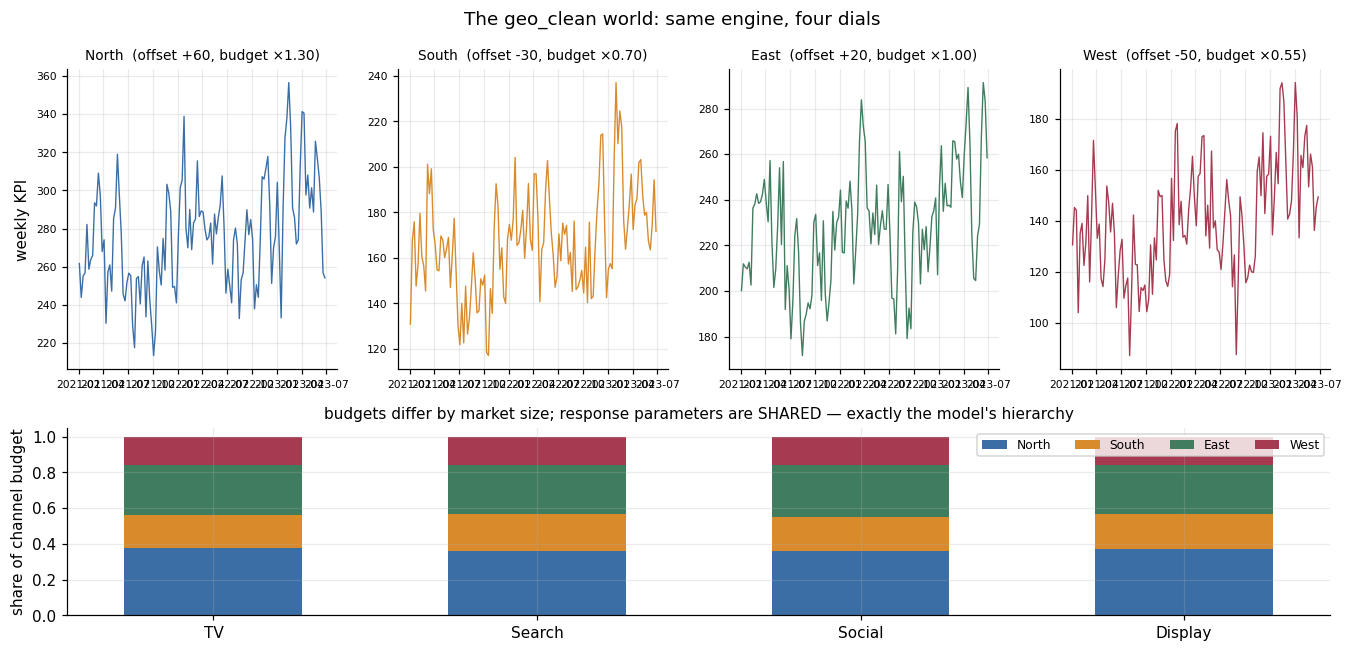

In [5]:
sc1 = dgp_geo.build("geo_clean")
labels1 = cell_labels(sc1)

fig = plt.figure(figsize=(12.5, 6))
gs = fig.add_gridspec(2, 4, height_ratios=[1.6, 1])
for j, g in enumerate(sc1.geos):
    ax = fig.add_subplot(gs[0, j])
    m = labels1 == g
    ax.plot(sc1.weeks, sc1.y[m].to_numpy(), color=GPAL[g], lw=0.9)
    ax.set_title(f"{g}  (offset {sc1.notes['geo_offsets'][g]:+.0f}, "
                 f"budget ×{sc1.notes['geo_share'][g]:.2f})", fontsize=9)
    ax.tick_params(labelsize=7)
    if j == 0:
        ax.set_ylabel("weekly KPI")
ax = fig.add_subplot(gs[1, :])
spend_share = (sc1.spend.groupby(level="Geography").sum()
               .loc[sc1.geos].div(sc1.spend.sum()))
bottom = np.zeros(len(CH))
for g in sc1.geos:
    ax.bar(CH, spend_share.loc[g], bottom=bottom, color=GPAL[g], label=g, width=0.55)
    bottom += spend_share.loc[g].to_numpy()
ax.set_ylabel("share of channel budget"); ax.legend(fontsize=8, ncol=4)
ax.set_title("budgets differ by market size; response parameters are SHARED — "
             "exactly the model's hierarchy", fontsize=10)
fig.suptitle("The geo_clean world: same engine, four dials", fontsize=12)
plt.tight_layout(); plt.show()

In [6]:
m1, r1 = fit_panel(sc1.panel(), "geo_clean panel (130wk × 4 geos = 520 obs)")
g1, c1 = grade_national(sc1.true_contribution, m1, ("act1", "panel"),
                        "act1 panel, national")
assert r1.diagnostics["rhat_max"] < 1.05 and r1.diagnostics["divergences"] < 10
style_grade(g1)

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

...

Output()

Output()

Output()

act1 panel, national:  med|err| 6%   coverage 100%   total media +4%


,true,est,rel_err,covered,width
TV,"6,229","6,390",+3%,✓ in 90% HDI,0.44
Search,"4,772","5,178",+9%,✓ in 90% HDI,0.34
Social,"4,460","4,297",-4%,✓ in 90% HDI,0.32
Display,"3,017","3,315",+10%,✓ in 90% HDI,0.56


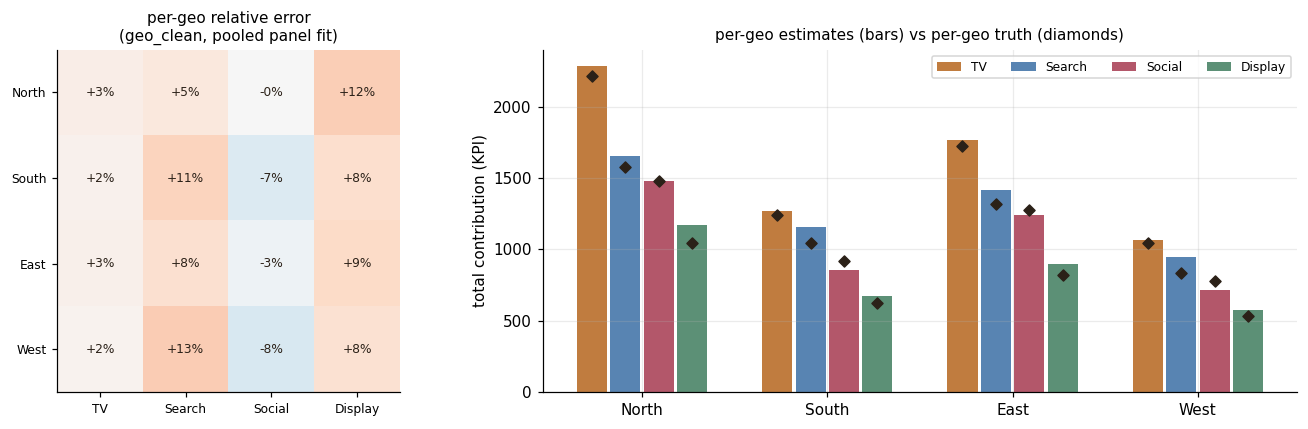

per-geo grades: median |rel err| 7%, 90% coverage 100%  (16 geo × channel cells)
✓ positive control passes nationally AND per geography — every later failure is the broken assumption, not the panel plumbing


In [7]:
pc1 = per_cell_table(sc1, m1, r1, contrib=c1)   # also verifies estimand identity
piv1 = pc1.pivot(index="cell", columns="channel", values="rel_err").loc[sc1.geos, CH]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0),
                         gridspec_kw={"width_ratios": [1, 1.5]})
err_heatmap(axes[0], piv1, "per-geo relative error\n(geo_clean, pooled panel fit)",
            vmax=0.5)
ax = axes[1]
x = np.arange(len(sc1.geos)); width = 0.18
for ci, c in enumerate(CH):
    sub = pc1[pc1.channel == c].set_index("cell").loc[sc1.geos]
    ax.bar(x + (ci - 1.5) * width, sub["est"], width * 0.9, color=PAL[c],
           alpha=0.85, label=c)
    ax.scatter(x + (ci - 1.5) * width, sub["true"], marker="D", s=26, color=INK,
               zorder=5)
ax.set_xticks(x); ax.set_xticklabels(sc1.geos)
ax.set_ylabel("total contribution (KPI)"); ax.legend(fontsize=8, ncol=4)
ax.set_title("per-geo estimates (bars) vs per-geo truth (diamonds)", fontsize=10)
plt.tight_layout(); plt.show()

med_geo = float(pc1.rel_err.abs().median())
cov_geo = float(pc1.covered.mean())
print(f"per-geo grades: median |rel err| {med_geo:.0%}, "
      f"90% coverage {cov_geo:.0%}  ({len(pc1)} geo × channel cells)")

# CLAIM: the panel machinery recovers truth at BOTH levels of the readout.
s = SUMMARY[("act1", "panel")]
assert s["med_abs_err"] < 0.20 and s["coverage"] >= 0.75    # national
assert med_geo < 0.20 and cov_geo >= 0.75                   # per geography
print("✓ positive control passes nationally AND per geography — every later "
      "failure is the broken assumption, not the panel plumbing")

**The fit, seen per geography.** The national R² of a panel fit can hide a
geo it systematically misses. Small-multiple fit bands — same posterior,
sliced by geo — are the panel version of stress_00 §3.1's "View 1", and the
contribution-path bands below them are its "View 2", drawn against each geo's
true path (knowable here, never in production).

Output()

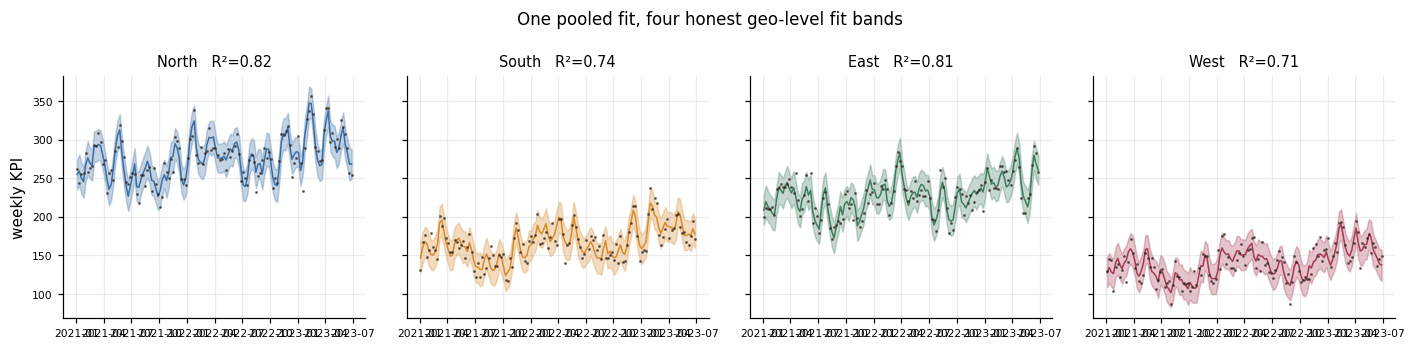

per-geo R²: {'North': np.float64(0.82), 'South': np.float64(0.74), 'East': np.float64(0.81), 'West': np.float64(0.71)}


In [8]:
with quiet():
    pred1 = m1.predict(random_seed=0)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.2), sharey=True)
r2_by_geo = {}
for ax, g in zip(axes, sc1.geos):
    m = labels1 == g
    lo, hi = np.percentile(pred1.y_pred_samples[:, m], [5, 95], axis=0)
    mu = pred1.y_pred_mean[m]
    obs = sc1.y[m].to_numpy()
    r2_by_geo[g] = 1 - np.var(obs - mu) / np.var(obs)
    ax.fill_between(sc1.weeks, lo, hi, color=GPAL[g], alpha=0.3)
    ax.plot(sc1.weeks, mu, color=GPAL[g], lw=1.0)
    ax.plot(sc1.weeks, obs, ".", color=INK, ms=1.8, alpha=0.6)
    ax.set_title(f"{g}   R²={r2_by_geo[g]:.2f}", fontsize=9.5)
    ax.tick_params(labelsize=7)
axes[0].set_ylabel("weekly KPI")
fig.suptitle("One pooled fit, four honest geo-level fit bands", fontsize=11)
plt.tight_layout(); plt.show()
assert all(v > 0.6 for v in r2_by_geo.values())
print("per-geo R²:", {g: round(v, 2) for g, v in r2_by_geo.items()})

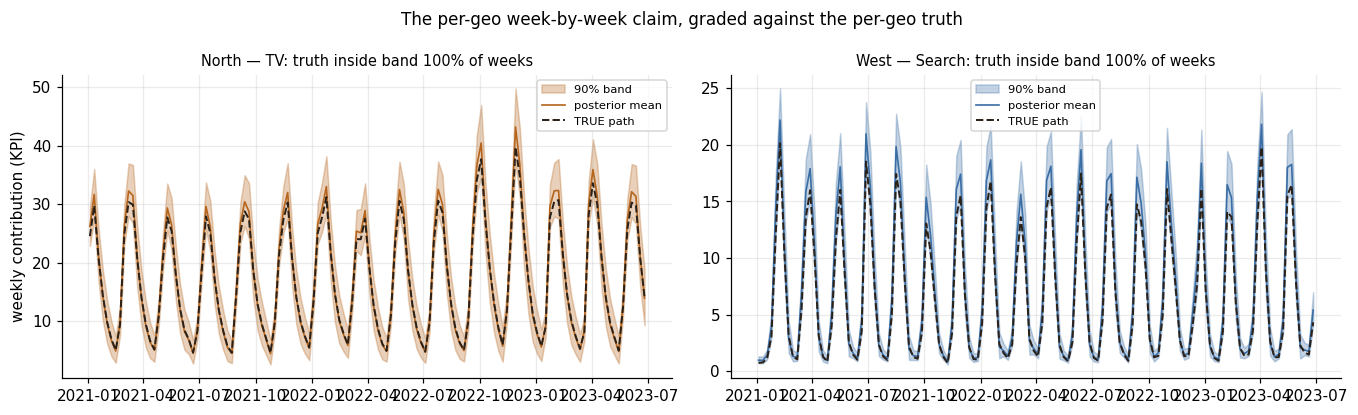

✓ inside a representable world the per-geo contribution bands are honest


In [9]:
# Contribution-over-time bands inside one geography, vs that geo's true path.
draws1 = contrib_draws(m1, r1)
SHOW = [("North", "TV"), ("West", "Search")]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
band_cov1 = {}
for ax, (g, c) in zip(axes, SHOW):
    m = labels1 == g
    ci = CH.index(c)
    lo, hi = np.percentile(draws1[:, m, ci], [5, 95], axis=0)
    mean = draws1[:, m, ci].mean(axis=0)
    tp = true_cell_path(sc1, g, c)
    band_cov1[(g, c)] = float(((tp >= lo) & (tp <= hi)).mean())
    ax.fill_between(sc1.weeks, lo, hi, color=PAL[c], alpha=0.3, label="90% band")
    ax.plot(sc1.weeks, mean, color=PAL[c], lw=1.1, label="posterior mean")
    ax.plot(sc1.weeks, tp, color=INK, ls="--", lw=1.3, label="TRUE path")
    ax.set_title(f"{g} — {c}: truth inside band "
                 f"{band_cov1[(g, c)]:.0%} of weeks", fontsize=9.5)
    ax.legend(fontsize=7.5)
axes[0].set_ylabel("weekly contribution (KPI)")
fig.suptitle("The per-geo week-by-week claim, graded against the per-geo truth",
             fontsize=11)
plt.tight_layout(); plt.show()
assert all(v >= 0.6 for v in band_cov1.values())
print("✓ inside a representable world the per-geo contribution bands are honest")

---
# Act 2 — What aggregation throws away

Most teams *have* geo-level data and model nationally anyway. Sum the
`geo_clean` world across its four geographies — same weeks, same total spend,
same causal truth (zeroing a channel everywhere is the sum of its per-geo
zero-outs) — and refit. Two structural things are lost:

1. **Replication.** 520 observations become 130; the four independent
   flighting calendars blur into one smoother national curve.
2. **The curve itself.** Each geo responds on *its own* saturation position;
   a sum of four saturation curves evaluated at four different operating
   points is **not** a saturation curve of the summed spend (Jensen). The
   aggregated world is, strictly, *outside the model's family* — even though
   every geo individually was inside it.

In [10]:
nat1 = sc1.national_scenario()
m2, r2 = fit_panel(nat1.panel(), "geo_clean NATIONAL aggregate (130 obs)")
g2, c2 = grade_national(nat1.true_contribution, m2, ("act2", "national"),
                        "act2 national aggregate")
style_grade(g2)

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

...

Output()

Output()

Output()

act2 national aggregate:  med|err| 8%   coverage 100%   total media -6%


,true,est,rel_err,covered,width
TV,"6,229","5,458",-12%,✓ in 90% HDI,0.47
Search,"4,772","4,991",+5%,✓ in 90% HDI,0.93
Social,"4,460","4,437",-1%,✓ in 90% HDI,0.72
Display,"3,017","2,430",-19%,✓ in 90% HDI,0.98


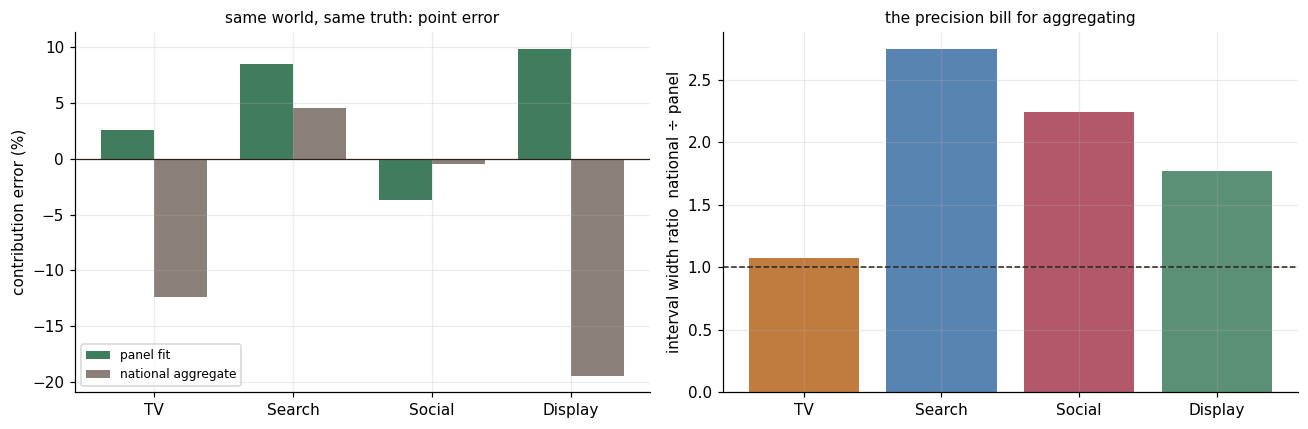

interval width ratio (national / panel): {'TV': 1.08, 'Search': 2.74, 'Social': 2.24, 'Display': 1.77}
✓ worst-channel |error|: panel 10% vs national 19%; intervals widen ~2.0× on the median channel


In [11]:
p, n = SUMMARY[("act1", "panel")]["df"], SUMMARY[("act2", "national")]["df"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(CH)); w = 0.38
axes[0].bar(x - w/2, p.rel_err * 100, w, color=LEAF, label="panel fit")
axes[0].bar(x + w/2, n.rel_err * 100, w, color=MUTED, label="national aggregate")
axes[0].axhline(0, color=INK, lw=0.8)
axes[0].set_xticks(x); axes[0].set_xticklabels(CH)
axes[0].set_ylabel("contribution error (%)")
axes[0].set_title("same world, same truth: point error", fontsize=10)
axes[0].legend(fontsize=8)
ratio = (n.width / p.width)
axes[1].bar(CH, ratio, color=[PAL[c] for c in CH], alpha=0.85)
axes[1].axhline(1.0, color=INK, lw=1, ls="--")
axes[1].set_ylabel("interval width ratio  national ÷ panel")
axes[1].set_title("the precision bill for aggregating", fontsize=10)
plt.tight_layout(); plt.show()

print("interval width ratio (national / panel):",
      {c: round(float(ratio[c]), 2) for c in CH})
# CLAIM 1: aggregation costs real precision on most channels.
assert (ratio > 1.3).sum() >= 3, ratio.to_dict()
# CLAIM 2: the panel's worst channel beats the aggregate's worst channel.
assert p.rel_err.abs().max() < n.rel_err.abs().max()
assert n.rel_err.abs().max() > 0.10
print(f"✓ worst-channel |error|: panel {p.rel_err.abs().max():.0%} vs national "
      f"{n.rel_err.abs().max():.0%}; intervals widen ~{ratio.median():.1f}× on the "
      "median channel")

> **Act 2 takeaway.** Aggregation here doesn't *break* the model — coverage
> survives because the intervals widen to admit what was lost — but you pay
> twice: materially wider intervals on most channels, and the largest point
> errors drifting to the channels whose geo-level operating points differed
> most (the Jensen gap). If geo data exists, the panel fit is not a luxury;
> it is the cheaper way to buy the precision you'd otherwise need more years
> of history for. (And note the quiet doctrine point: *both* fits are green;
> only the known truth reveals which numbers drifted.)

---
# Act 3 — The regional ROI trap: one beta, four markets

**The world.** `geo_heterogeneous` keeps act 1's skeleton and changes what the
model cannot see: **channel effectiveness now differs by geography**
(multipliers 0.3–1.8× on the shared response — TV is a powerhouse in the North
and nearly dead in the West; Search inverts), and budgets **chase
performance** the way real regional allocation does: geos where a channel
works get a larger share of its budget.

The model's hierarchy is an *intercept* per geo and **one global beta per
channel**. Per-geo effectiveness is structurally outside its hypothesis space
— the pooled beta will land near a spend-weighted average, and *every geo's
readout inherits it*.

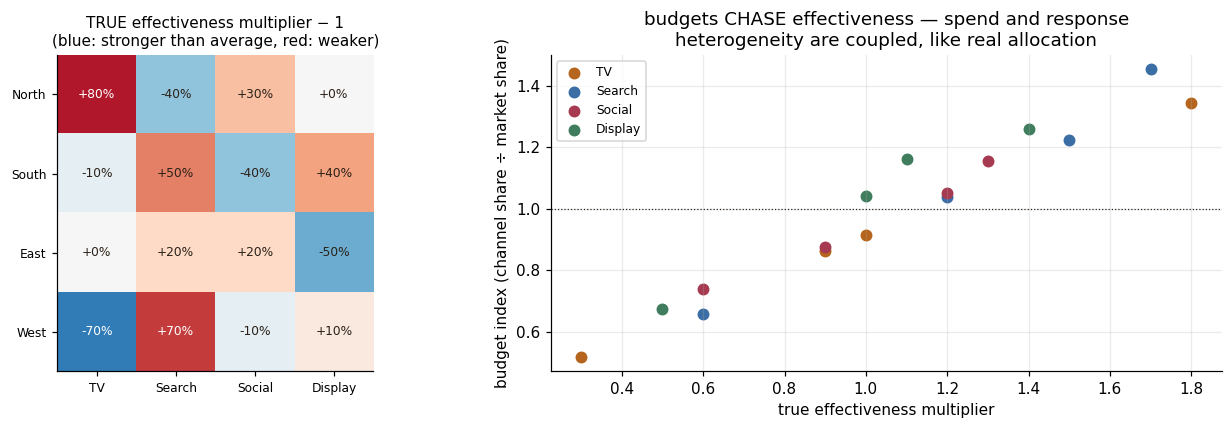

market-size-adjusted budget share rises with effectiveness in every channel — by construction


In [12]:
sc3 = dgp_geo.build("geo_heterogeneous")
labels3 = cell_labels(sc3)
mult = pd.DataFrame(sc3.notes["effect_multipliers"]).T.loc[sc3.geos, CH]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
im = err_heatmap(axes[0], mult - 1.0,
                 "TRUE effectiveness multiplier − 1\n(blue: stronger than "
                 "average, red: weaker)", vmax=1.0)
spend_share3 = sc3.spend.groupby(level="Geography").sum().loc[sc3.geos]
market = pd.Series(sc3.notes["geo_share"]).loc[sc3.geos]
# Budget index: the geo's share of the channel's budget relative to its share
# of the market — > 1 means the channel over-indexes there vs pure market size.
budget_index = (spend_share3.div(spend_share3.sum())).div(
    market / market.sum(), axis=0)
ax = axes[1]
for c in CH:
    ax.scatter(mult[c], budget_index[c], s=46, color=PAL[c], label=c)
ax.axhline(1.0, color=INK, lw=0.8, ls=":")
ax.set(xlabel="true effectiveness multiplier",
       ylabel="budget index (channel share ÷ market share)",
       title="budgets CHASE effectiveness — spend and response\nheterogeneity "
             "are coupled, like real allocation")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

for c in CH:   # allocation is genuinely performance-coupled in this world
    assert np.corrcoef(mult[c], budget_index[c])[0, 1] > 0.5
print("market-size-adjusted budget share rises with effectiveness in every "
      "channel — by construction")

In [13]:
m3, r3 = fit_panel(sc3.panel(), "geo_heterogeneous panel (pooled)")
g3, c3 = grade_national(sc3.true_contribution, m3, ("act3", "pooled"),
                        "act3 pooled, national")
assert r3.diagnostics["rhat_max"] < 1.05 and r3.diagnostics["divergences"] < 10
style_grade(g3)

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

...

Output()

Output()

Output()

act3 pooled, national:  med|err| 5%   coverage 100%   total media -0%


,true,est,rel_err,covered,width
TV,"7,046","7,585",+8%,✓ in 90% HDI,0.35
Search,"8,688","8,431",-3%,✓ in 90% HDI,0.27
Social,"3,986","3,793",-5%,✓ in 90% HDI,0.37
Display,"2,779","2,623",-6%,✓ in 90% HDI,0.51


Read the national table above: it is **excellent** — small errors, full
coverage, clean sampler. An analyst grading this model nationally would ship
it. Now grade the same posterior at the level the budget meeting actually
uses:

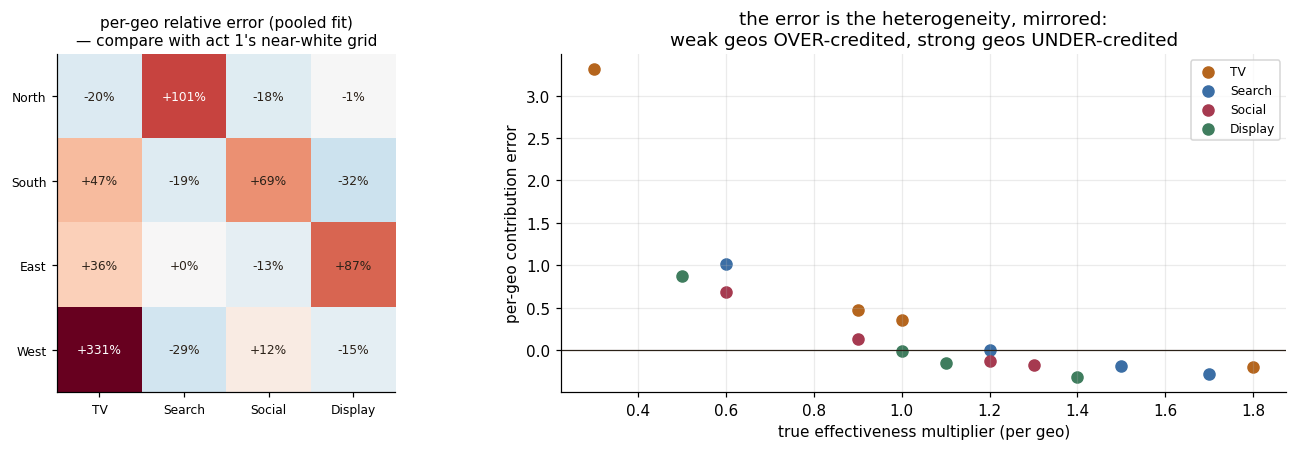

per-geo: med|err| 24%, coverage 31%; worst cell West/TV at +331%
corr(true multiplier, per-geo error) by channel: {'TV': -0.87, 'Search': -0.97, 'Social': -0.97, 'Display': -0.97}

✓ a national-green model whose per-geo readouts are inverted images of the truth


In [14]:
pc3 = per_cell_table(sc3, m3, r3, contrib=c3)
piv3 = pc3.pivot(index="cell", columns="channel", values="rel_err").loc[sc3.geos, CH]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.2),
                         gridspec_kw={"width_ratios": [1, 1.15]})
err_heatmap(axes[0], piv3, "per-geo relative error (pooled fit)\n— compare with "
            "act 1's near-white grid", vmax=1.5)
ax = axes[1]
for c in CH:
    sub = pc3[pc3.channel == c].set_index("cell").loc[sc3.geos]
    ax.scatter(mult[c], sub["rel_err"], s=52, color=PAL[c], label=c)
ax.axhline(0, color=INK, lw=0.8)
ax.set(xlabel="true effectiveness multiplier (per geo)",
       ylabel="per-geo contribution error",
       title="the error is the heterogeneity, mirrored:\nweak geos OVER-credited, "
             "strong geos UNDER-credited")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

med3 = float(pc3.rel_err.abs().median()); cov3 = float(pc3.covered.mean())
worst = pc3.loc[pc3.rel_err.abs().idxmax()]
slopes = {c: float(np.corrcoef(mult[c],
          piv3[c].loc[sc3.geos])[0, 1]) for c in CH}
print(f"per-geo: med|err| {med3:.0%}, coverage {cov3:.0%}; worst cell "
      f"{worst.cell}/{worst.channel} at {worst.rel_err:+.0%}")
print("corr(true multiplier, per-geo error) by channel:",
      {c: round(v, 2) for c, v in slopes.items()})

# CLAIM 1 (the silent part): national is fine, regional is not.
s3 = SUMMARY[("act3", "pooled")]
assert s3["med_abs_err"] < 0.15 and s3["coverage"] >= 0.75
assert med3 > 0.18 and cov3 <= 0.60
assert abs(worst.rel_err) > 1.0          # at least one geo readout is off >100%
# CLAIM 2: the bias is SYSTEMATIC — anti-correlated with true effectiveness.
assert sum(v < -0.5 for v in slopes.values()) >= 3
print("\n✓ a national-green model whose per-geo readouts are inverted images "
      "of the truth")

**Why the sign is the worst possible sign.** The pooled beta is a compromise:
above the truth in weak geos, below it in strong ones. So the per-geo table
**over-credits exactly the markets where the channel works least** — and a
budget optimizer reading it would move money *toward* the geos the channel is
failing in and *away* from where it prints. The readout isn't merely noisy;
it argues for the value-destroying reallocation. Watch what that does to
regional ROI *ranking* — the one-number summary regional teams are judged on:

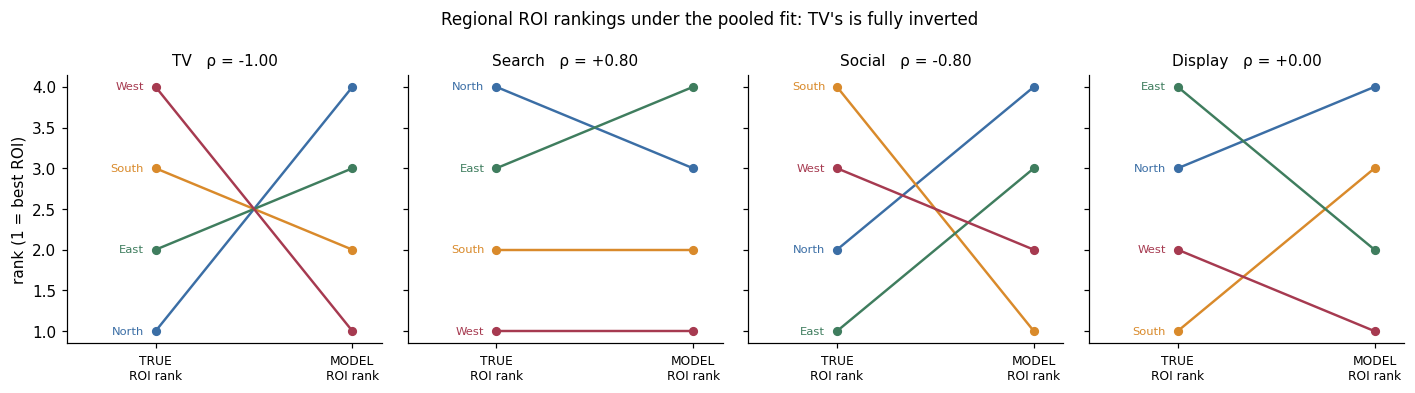

Spearman ρ (true vs estimated per-geo ROI ranking): {'TV': -1.0, 'Search': 0.8, 'Social': -0.8, 'Display': 0.0}
✓ the channel with the widest true heterogeneity (TV, 0.3–1.8×) gets the most confidently wrong regional ranking


In [15]:
from scipy.stats import spearmanr

spend_geo3 = sc3.spend.groupby(level="Geography").sum().loc[sc3.geos]
est3 = pc3.pivot(index="cell", columns="channel", values="est").loc[sc3.geos, CH]
roas_true = sc3.true_roas_by_geo.loc[sc3.geos, CH]
roas_est = est3 / spend_geo3

rhos = {c: float(spearmanr(roas_true[c], roas_est[c]).statistic) for c in CH}

fig, axes = plt.subplots(1, 4, figsize=(13, 3.6), sharey=True)
for ax, c in zip(axes, CH):
    rt = roas_true[c].rank(ascending=False)
    re = roas_est[c].rank(ascending=False)
    for g in sc3.geos:
        ax.plot([0, 1], [rt[g], re[g]], "-o", color=GPAL[g], lw=1.6, ms=5,
                label=g if c == "TV" else None)
        ax.annotate(g, (-0.06, rt[g]), ha="right", va="center", fontsize=7.5,
                    color=GPAL[g])
    ax.set_xticks([0, 1]); ax.set_xticklabels(["TRUE\nROI rank", "MODEL\nROI rank"],
                                              fontsize=8)
    ax.set_xlim(-0.45, 1.15); ax.invert_yaxis()
    ax.set_title(f"{c}   ρ = {rhos[c]:+.2f}", fontsize=10)
    ax.grid(False)
axes[0].set_ylabel("rank (1 = best ROI)")
fig.suptitle("Regional ROI rankings under the pooled fit: TV's is fully inverted",
             fontsize=11)
plt.tight_layout(); plt.show()

print("Spearman ρ (true vs estimated per-geo ROI ranking):",
      {c: round(v, 2) for c, v in rhos.items()})
# CLAIM: rankings are unreliable-to-inverted; TV's is upside down.
assert rhos["TV"] <= -0.5
assert np.mean(list(rhos.values())) < 0.3
print("✓ the channel with the widest true heterogeneity (TV, 0.3–1.8×) gets the "
      "most confidently wrong regional ranking")

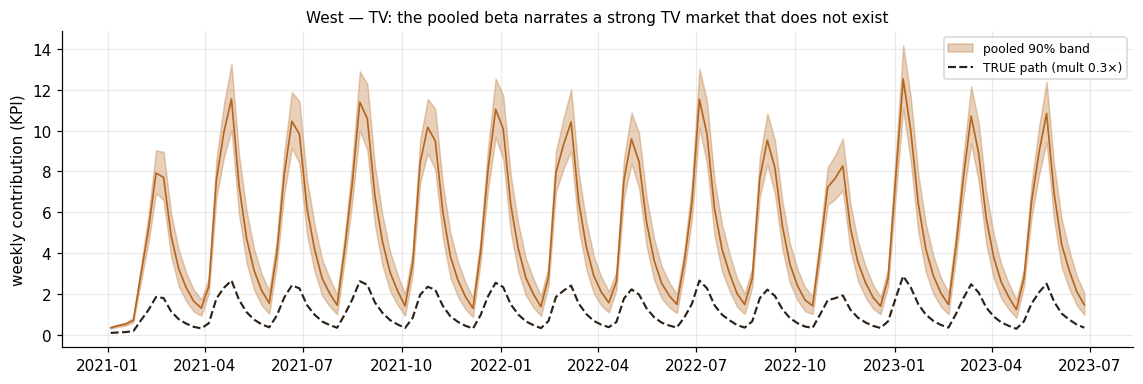

truth below the band 100% of weeks


In [16]:
# The per-geo claim over time, where it's worst: West TV (weak market whose
# budget the optimizer would grow). The pooled band floats far above the truth.
draws3 = contrib_draws(m3, r3)
g, c = "West", "TV"
mwest = labels3 == g; ci = CH.index(c)
lo, hi = np.percentile(draws3[:, mwest, ci], [5, 95], axis=0)
tp = true_cell_path(sc3, g, c)
fig, ax = plt.subplots(figsize=(10.5, 3.6))
ax.fill_between(sc3.weeks, lo, hi, color=PAL[c], alpha=0.3, label="pooled 90% band")
ax.plot(sc3.weeks, draws3[:, mwest, ci].mean(axis=0), color=PAL[c], lw=1.1)
ax.plot(sc3.weeks, tp, color=INK, ls="--", lw=1.4, label="TRUE path (mult 0.3×)")
ax.set_title(f"{g} — {c}: the pooled beta narrates a strong TV market that "
             "does not exist", fontsize=10)
ax.set_ylabel("weekly contribution (KPI)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
above = float((tp < lo).mean())
print(f"truth below the band {above:.0%} of weeks")
assert above >= 0.5

## Pivot — split the panel: one model per geography

The framework has no per-geo response coefficients (`beta_<ch>` is global;
the hierarchy pools **intercepts** only), so the structural pivot available
today is to *refit per geography*: four small models, each free to find its
own beta. The textbook trade — splitting buys back the bias at the price of
4× fewer observations per fit — measured live:

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

...

fit 'per-geo fit: West (130 obs)': 9s   r-hat max 1.016   divergences 0   min bulk ESS 299


Output()

Output()

Output()

Output()

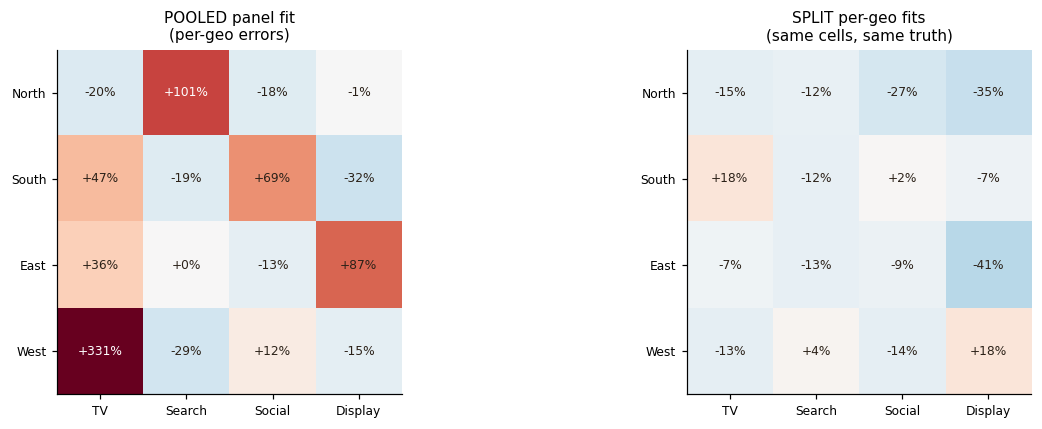

,pooled panel,split per-geo
med |err|,24%,13%
coverage,31%,94%
worst |err|,331%,41%


TV regional ROI ranking: pooled ρ -1.00 -> split ρ +0.80
✓ four small honest models beat one large confidently-wrong one — for the regional question


In [17]:
split_rows = []
for g in sc3.geos:
    slg = sc3.geo_scenario(g)
    mg, rg = fit_panel(slg.panel(), f"per-geo fit: {g} (130 obs)")
    with quiet():
        cg = mg.compute_counterfactual_contributions(
            compute_uncertainty=True, hdi_prob=0.9, random_seed=0)
    for c in CH:
        t = float(slg.true_contribution[c]); e = float(cg.total_contributions[c])
        lo = float(cg.contribution_hdi_low[c]); hi = float(cg.contribution_hdi_high[c])
        split_rows.append(dict(cell=g, channel=c, true=t, est=e,
                               rel_err=(e - t) / abs(t), covered=lo <= t <= hi))
split3 = pd.DataFrame(split_rows)
piv3s = split3.pivot(index="cell", columns="channel", values="rel_err").loc[sc3.geos, CH]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.0))
err_heatmap(axes[0], piv3, "POOLED panel fit\n(per-geo errors)", vmax=1.5)
err_heatmap(axes[1], piv3s, "SPLIT per-geo fits\n(same cells, same truth)", vmax=1.5)
plt.tight_layout(); plt.show()

med_split = float(split3.rel_err.abs().median())
cov_split = float(split3.covered.mean())
cmp3 = pd.DataFrame({
    "pooled panel": {"med |err|": f"{med3:.0%}", "coverage": f"{cov3:.0%}",
                     "worst |err|": f"{piv3.abs().max().max():.0%}"},
    "split per-geo": {"med |err|": f"{med_split:.0%}", "coverage": f"{cov_split:.0%}",
                      "worst |err|": f"{piv3s.abs().max().max():.0%}"},
})
display(cmp3)

# CLAIM: splitting repairs the regional readout (and the ROI rankings with it).
assert med_split < med3 - 0.05
assert cov_split >= cov3 + 0.30
roas_split = (split3.pivot(index="cell", columns="channel", values="est")
              .loc[sc3.geos, CH] / spend_geo3)
rho_split_tv = float(spearmanr(roas_true["TV"], roas_split["TV"]).statistic)
print(f"TV regional ROI ranking: pooled ρ {rhos['TV']:+.2f} -> split "
      f"ρ {rho_split_tv:+.2f}")
assert rho_split_tv > 0.5
print("✓ four small honest models beat one large confidently-wrong one — "
      "for the regional question")

> **Act 3 takeaway.** *Pooling is a modeling decision dressed as a default.*
> The panel model's global beta answers the **national** question well even
> under strong heterogeneity — and silently converts every **regional** table
> into the national answer wearing local clothes, with the bias pointing the
> worst possible way (over-credit where the channel is weak, because that is
> where the pooled beta exceeds the local truth). The tells, in order of
> availability: (1) *design knowledge* — if budgets are allocated on
> performance, heterogeneity is coupled to spend by construction; (2) a
> **split-sample check** — refit per geo (or per region group) and compare
> against the pooled per-geo table, exactly as done here; (3) per-geo lift
> tests where the money justifies them. The durable fix is hierarchical
> *response* pooling (per-geo betas with shrinkage) — the framework's
> hierarchy currently pools intercepts only, which this act is the design
> case for.

---
# Act 4 — Geography × product: six cells, end to end

**The world.** `geo_product` is the positive control at the full
cross-classification: 3 geographies × 2 products, two years weekly (624
observations). Baseline level = geo offset **+** product offset (exactly the
model's additive geo + product hierarchy); response parameters shared; each
*product line* flights independently and tilts its channel mix (Core is
TV-heavy, Premium is Search/Social-heavy) — so the cells genuinely differ in
what their budgets buy, and truth is recorded **per cell**.

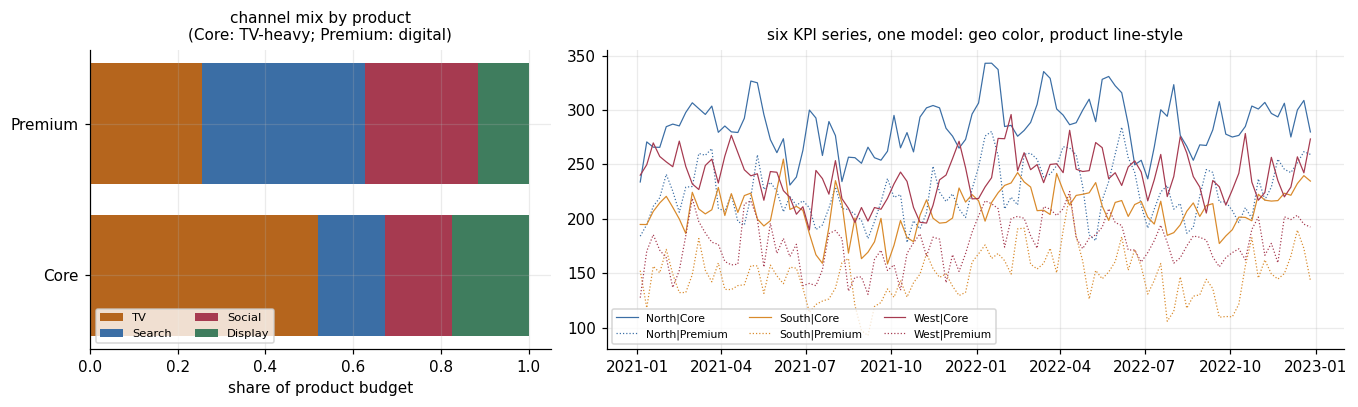

In [18]:
sc4 = dgp_geo.build("geo_product")
labels4 = cell_labels(sc4)

mix = (sc4.spend.groupby(level="Product").sum())
mix = mix.div(mix.sum(axis=1), axis=0)
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8),
                         gridspec_kw={"width_ratios": [1, 1.6]})
bottom = np.zeros(len(mix))
for c in CH:
    axes[0].barh(mix.index, mix[c], left=bottom, color=PAL[c], label=c)
    bottom += mix[c].to_numpy()
axes[0].set_title("channel mix by product\n(Core: TV-heavy; Premium: digital)",
                  fontsize=10)
axes[0].legend(fontsize=7.5, ncol=2); axes[0].set_xlabel("share of product budget")
ax = axes[1]
for cell in sc4.cells:
    m = labels4 == cell
    g = cell.split("|")[0]
    ax.plot(sc4.weeks, sc4.y[m].to_numpy(),
            color=GPAL[g], lw=0.8,
            ls="-" if cell.endswith("Core") else ":",
            label=cell)
ax.legend(fontsize=7, ncol=3); ax.set_title(
    "six KPI series, one model: geo color, product line-style", fontsize=10)
plt.tight_layout(); plt.show()

In [19]:
m4, r4 = fit_panel(sc4.panel(), "geo_product panel (104wk × 6 cells = 624 obs)")
g4, c4 = grade_national(sc4.true_contribution, m4, ("act4", "panel"),
                        "act4 geo×product, national")
assert r4.diagnostics["rhat_max"] < 1.05 and r4.diagnostics["divergences"] < 10
assert m4.n_cells == 6 and m4.has_geo and m4.has_product
style_grade(g4)

  0%|          | 0/600 [00:00<?, ?it/s]

  0%|          | 0/600 [00:00<?, ?it/s]

We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Output()

...

Output()

Output()

Output()

act4 geo×product, national:  med|err| 7%   coverage 100%   total media +1%


,true,est,rel_err,covered,width
TV,"7,273","7,144",-2%,✓ in 90% HDI,0.34
Search,"6,238","6,603",+6%,✓ in 90% HDI,0.32
Social,"4,890","4,453",-9%,✓ in 90% HDI,0.29
Display,"2,680","3,002",+12%,✓ in 90% HDI,0.72


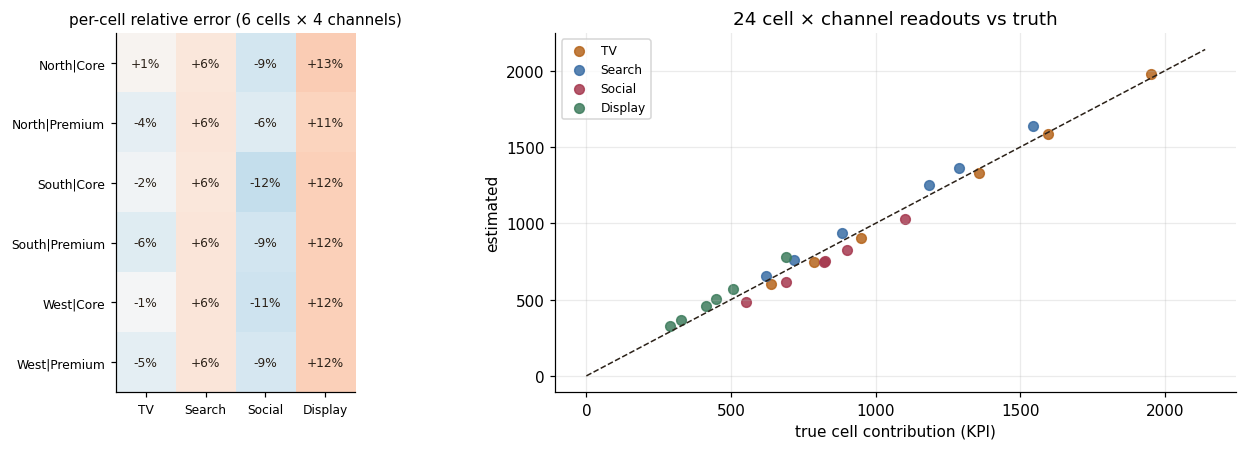

per-cell: med|err| 6%, coverage 100% across 24 cell × channel readouts
✓ geo × product machinery sound end to end: build, fit, per-cell grading


In [20]:
pc4 = per_cell_table(sc4, m4, r4, contrib=c4)
piv4 = pc4.pivot(index="cell", columns="channel", values="rel_err").loc[sc4.cells, CH]

fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.2),
                         gridspec_kw={"width_ratios": [1.1, 1]})
err_heatmap(axes[0], piv4, "per-cell relative error (6 cells × 4 channels)",
            vmax=0.5)
ax = axes[1]
for c in CH:
    sub = pc4[pc4.channel == c]
    ax.scatter(sub["true"], sub["est"], s=40, color=PAL[c], label=c, alpha=0.85)
lims = [0, float(pc4[["true", "est"]].max().max()) * 1.08]
ax.plot(lims, lims, color=INK, lw=1, ls="--")
ax.set(xlabel="true cell contribution (KPI)", ylabel="estimated",
       title="24 cell × channel readouts vs truth")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

med4 = float(pc4.rel_err.abs().median()); cov4 = float(pc4.covered.mean())
print(f"per-cell: med|err| {med4:.0%}, coverage {cov4:.0%} across "
      f"{len(pc4)} cell × channel readouts")

# CLAIM: the cross-classified hierarchy recovers truth per cell when the
# world matches it (and act 3 told you what happens when it doesn't).
s4 = SUMMARY[("act4", "panel")]
assert s4["med_abs_err"] < 0.15 and s4["coverage"] >= 0.75
assert med4 < 0.15 and cov4 >= 0.80
print("✓ geo × product machinery sound end to end: build, fit, per-cell grading")

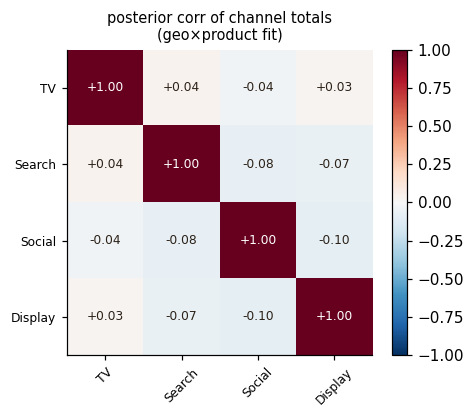

pairwise: [ 0.04 -0.04  0.03 -0.08 -0.07 -0.1 ]
✓ six independent cell calendars keep the channels separable — compare the collinear seesaw in stress_03


In [21]:
# Closing uncertainty lens (stress_00 §3.1's View 3, panel edition): with six
# distinct cell calendars the channel totals should be cleanly separable.
totals4 = contrib_draws(m4, r4).sum(axis=1)
corr4 = pd.DataFrame(np.corrcoef(totals4.T), index=CH, columns=CH)
fig, ax = plt.subplots(figsize=(4.6, 3.9))
im = ax.imshow(corr4, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(4)); ax.set_xticklabels(CH, rotation=45, fontsize=8)
ax.set_yticks(range(4)); ax.set_yticklabels(CH, fontsize=8)
for (i, j), v in np.ndenumerate(corr4.values):
    ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=8,
            color="white" if abs(v) > 0.6 else INK)
ax.set_title("posterior corr of channel totals\n(geo×product fit)", fontsize=9.5)
ax.grid(False); fig.colorbar(im, fraction=0.046)
plt.tight_layout(); plt.show()
off4 = corr4.values[np.triu_indices(4, 1)]
print("pairwise:", np.round(off4, 2))
assert np.abs(off4).max() < 0.5    # separable — contrast stress_03's seesaw
print("✓ six independent cell calendars keep the channels separable — compare "
      "the collinear seesaw in stress_03")

---
# Synthesis — the panel scorecard

In [22]:
score = pd.DataFrame({
    "act 1 — geo positive control (panel)": {
        "national med|err|": SUMMARY[("act1", "panel")]["med_abs_err"],
        "regional med|err|": float(pc1.rel_err.abs().median()),
        "regional coverage": float(pc1.covered.mean()),
        "verdict": "🟢 recovers at both levels"},
    "act 2 — same world, aggregated": {
        "national med|err|": SUMMARY[("act2", "national")]["med_abs_err"],
        "regional med|err|": np.nan,
        "regional coverage": np.nan,
        "verdict": "🟡 green but ~2× wider intervals; worst channel drifts"},
    "act 3 — heterogeneity, pooled": {
        "national med|err|": SUMMARY[("act3", "pooled")]["med_abs_err"],
        "regional med|err|": med3,
        "regional coverage": cov3,
        "verdict": "🔴 SILENT at the regional level (TV ROI rank inverted)"},
    "act 3 — heterogeneity, split fits": {
        "national med|err|": np.nan,
        "regional med|err|": med_split,
        "regional coverage": cov_split,
        "verdict": "🟢 regional readout repaired"},
    "act 4 — geo×product positive control": {
        "national med|err|": SUMMARY[("act4", "panel")]["med_abs_err"],
        "regional med|err|": med4,
        "regional coverage": cov4,
        "verdict": "🟢 recovers per cell"},
}).T
fmt = {c: "{:.0%}" for c in
       ["national med|err|", "regional med|err|", "regional coverage"]}
display(score.style.format(fmt, na_rep="—"))

# The scorecard's one-line story, asserted:
assert score.loc["act 3 — heterogeneity, pooled", "regional med|err|"] > \
       2 * score.loc["act 1 — geo positive control (panel)", "regional med|err|"]
print("the panel machinery is sound; the REGIONAL claim is only as good as the "
      "pooling assumption behind it")

,national med|err|,regional med|err|,regional coverage,verdict
act 1 — geo positive control (panel),6%,7%,100%,🟢 recovers at both levels
"act 2 — same world, aggregated",8%,—,—,🟡 green but ~2× wider intervals; worst channel drifts
"act 3 — heterogeneity, pooled",5%,24%,31%,🔴 SILENT at the regional level (TV ROI rank inverted)
"act 3 — heterogeneity, split fits",—,13%,94%,🟢 regional readout repaired
act 4 — geo×product positive control,7%,6%,100%,🟢 recovers per cell


the panel machinery is sound; the REGIONAL claim is only as good as the pooling assumption behind it


## What to remember

1. **Impulse-test every time-structured transform on panel data.** Stacked
   observations are not a time axis. The cross-geo adstock bleed (act 0)
   survived years of shape-checking smoke tests and fell to a five-minute
   impulse test the first time a world had per-geo *truth* to contradict it.
   Positive controls are bug detectors, not formalities.
2. **Grade panels at the level the decisions are made.** A national grade is
   an average over the readouts people actually use. Act 3's model was
   excellent nationally and *inverted* regionally — same posterior, same
   green diagnostics.
3. **Know what your hierarchy pools.** This framework pools geo/product
   *intercepts*; response parameters are global. That is the right hypothesis
   space for act 1's world and structurally wrong for act 3's — and nothing
   in the data volunteers which world you are in. Performance-chased budgets
   make the wrong case the *expected* case.
4. **The heterogeneity bias points the worst possible way.** The pooled beta
   over-credits channels exactly where they are weakest (and the truth-rank
   charts show the ROI ranking inverting). A reallocation guided by it moves
   budget toward failure. If regional tables drive money, run the split-fit
   check before anyone reads them.
5. **Geo data buys identification — don't aggregate it away.** Same world,
   same weeks: the panel fit's intervals were ~half the national fit's width
   on most channels (act 2). Cross-sectional replication is the cheapest
   sample size you will ever get.
6. **The uncertainty lenses generalize.** Per-geo fit bands, per-geo
   contribution-path bands, and channel-total correlations (stress_00 §3.1,
   stress_03) all slice cleanly by cell — and the per-geo *band vs truth*
   view is what made act 3's failure visible at a glance.

**Series map:** [00 doctrine](stress_00_the_rosy_picture.ipynb) ·
[01 carryover & shape](stress_01_carryover_and_shape.ipynb) ·
[02 time structure](stress_02_time_structure.ipynb) ·
[03 confounding & selection](stress_03_confounding_and_selection.ipynb) ·
[04 extension traps](stress_04_extension_traps.ipynb) ·
[05 the gauntlet](stress_05_the_gauntlet.ipynb) · **06 geography & hierarchy**
*(this one)*.